In [28]:
#MODEL AND FIRST RESULTS 

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("state_averages.csv")

In [30]:
# Affordability ratio (higher = better)
df['affordability'] = df['median_family_income'] / df['total_cost']

# Sort to see best states right now
df_sorted = df.sort_values(by='affordability', ascending=False)
print(df_sorted.head(10))

   state  case_id   isMetro  housing_cost     food_cost  transportation_cost  \
20    MD  1215.50  0.791667  16307.275197   8959.529328         13674.556017   
39    RI  2341.40  1.000000  16594.725254  10320.303487         12764.529648   
28    ND  2044.00  0.113208  10379.511632   8839.559502         14517.901461   
30    NH  1792.90  0.300000  14636.287375   9769.636487         13789.367647   
6     CT   315.75  0.875000  16953.564421   9703.825338         13606.714935   
12    IA   845.00  0.212121   9710.733269   7872.135327         13895.873568   
31    NJ  1812.00  1.000000  20041.624334   9574.312942         12655.240964   
23    MN  1379.00  0.310345  10909.731250   8496.356438         13860.518967   
35    OH  2114.50  0.431818  10219.128953   7613.183518         13150.143775   
43    TX  2679.50  0.322835  11119.062746   7673.697072         13660.942476   

    healthcare_cost  other_necessities_cost  childcare_cost         taxes  \
20      9015.969912             9155.15980

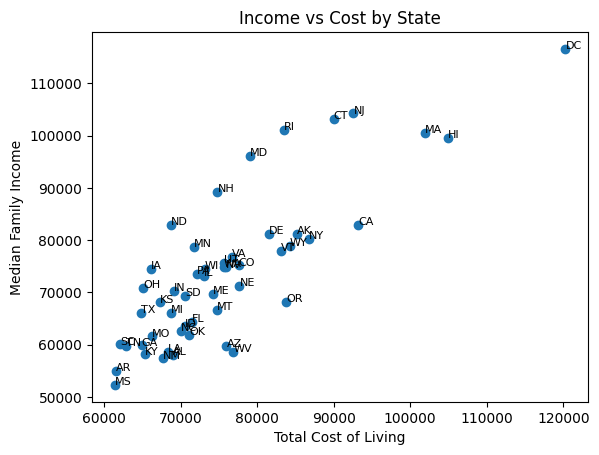

In [31]:
plt.figure()
plt.scatter(df['total_cost'], df['median_family_income'])

for i, row in df.iterrows():
    plt.text(row['total_cost'], row['median_family_income'], row['state'], fontsize=8)

plt.xlabel("Total Cost of Living")
plt.ylabel("Median Family Income")
plt.title("Income vs Cost by State")
plt.show()

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['housing_cost','food_cost','transportation_cost',
        'healthcare_cost','taxes']]

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

              Variable         VIF
0         housing_cost   71.201706
1            food_cost  205.796209
2  transportation_cost  111.972775
3      healthcare_cost   41.132230
4                taxes   35.193793


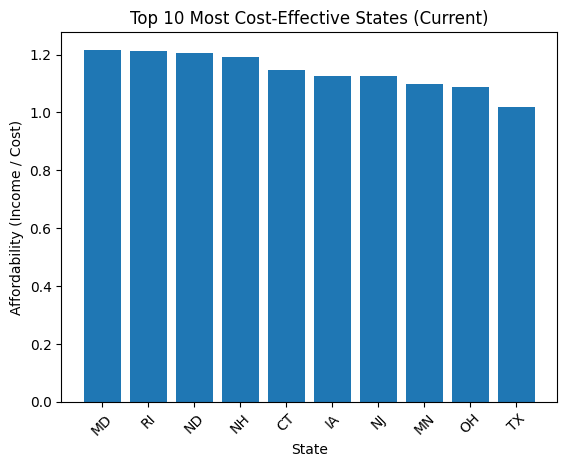

In [33]:
df['affordability'] = df['median_family_income'] / df['total_cost']
top_states = df.sort_values(by='affordability', ascending=False).head(10)
import matplotlib.pyplot as plt

plt.figure()

plt.bar(top_states['state'], top_states['affordability'])

plt.title("Top 10 Most Cost-Effective States (Current)")
plt.xlabel("State")
plt.ylabel("Affordability (Income / Cost)")

plt.xticks(rotation=45)

plt.show()

In [34]:
import statsmodels.api as sm

X = df[['total_cost']]
y = df['median_family_income']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     median_family_income   R-squared:                       0.688
Model:                              OLS   Adj. R-squared:                  0.682
Method:                   Least Squares   F-statistic:                     108.0
Date:                  Wed, 08 Apr 2026   Prob (F-statistic):           5.49e-14
Time:                          20:20:28   Log-Likelihood:                -531.11
No. Observations:                    51   AIC:                             1066.
Df Residuals:                        49   BIC:                             1070.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4899.1224   7661.988